# Plotagem dos resultados de avaliacao

Este notebook importa diretamente as funcoes de `tools/plot.py`. Assim, os graficos renderizam perto das chamadas no notebook, mas a logica de plotagem fica em um unico lugar.


## Configuracao

In [1]:
from pathlib import Path
import sys
import plot
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd  # type: ignore[import-untyped]
import seaborn as sns  # type: ignore[import-untyped]

def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tools/plot.py").is_file():
            return candidate
    raise FileNotFoundError(f"Raiz do projeto nao encontrada a partir de {start}")


def latest_result_dir(base: Path) -> Path:
    candidates = [p for p in base.iterdir() if (p / "matches.csv").is_file()]
    if not candidates:
        raise FileNotFoundError(f"Nenhuma pasta de resultado encontrada em {base}")
    return max(candidates, key=lambda p: (p / "matches.csv").stat().st_mtime)


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "tools"))
sns.set_theme(style="whitegrid", context="notebook")

RESULTS_BASE = PROJECT_ROOT / "tools/results"

# Para usar uma bateria especifica, substitua por algo como:
# RESULT_DIR = RESULTS_BASE / "cenario1__thief-thiefnew__vs__randomd__n50__seed1__..."
RESULT_DIR = latest_result_dir(RESULTS_BASE)
FIGS_DIR = RESULT_DIR / "figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

RESULT_DIR, FIGS_DIR


(PosixPath('/home/lucas/dev/web/agents/tools/results/england__random_t__vs__random_d__n1__seed1__d79943624fa0'),
 PosixPath('/home/lucas/dev/web/agents/tools/results/england__random_t__vs__random_d__n1__seed1__d79943624fa0/figs'))

In [2]:
dataset = plot.load_dataset(RESULT_DIR, pd)
matches = dataset["matches"]
summary = dataset["summary"]
best_worst = dataset["best_worst"]

display(summary)
display(matches.head())


,thief_agent,detective_agent,scenario,rounds,score_mean,score_best,score_worst,win_rate,draw_rate,loss_rate,turns_mean,robberies_mean,real_revealed_attrs_mean,risk_mean,no_progress_moves_mean,best_run_id,worst_run_id
0,agents/random_t.pl,agents/random_d.pl,maps/england.prolog,1,-425.0,-425.0,-425.0,0,0,1,31,0,0,0,23,69b471afb7be51e1,69b471afb7be51e1
1,agents/random_t.pl,ALL,maps/england.prolog,1,-425.0,-425.0,-425.0,0,0,1,31,0,0,0,23,69b471afb7be51e1,69b471afb7be51e1


,run_id,round,seed,scenario,thief_agent,detective_agent,winner,won,draw,lost,...,recent_revealed_city_turns,mandate_risk_events,no_progress_moves,illegal_actions,disguises_used,thief_start,detective_start,thief_id,target,loss_reason
0,69b471afb7be51e1,1,1,maps/england.prolog,agents/random_t.pl,agents/random_d.pl,detective,0,0,1,...,0,0,23,0,3,trafalgar_square,charing_cross,2,obra_de_arte,closed_city


## Distribuicao do score

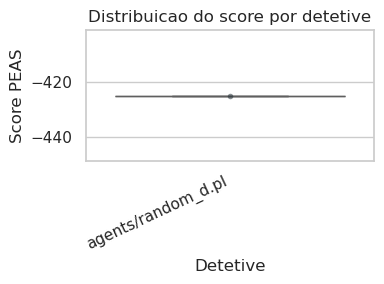

In [3]:
plot.plot_score_distribution(matches, FIGS_DIR, plt, sns, close=False)
plt.show()
plt.close()


## Taxa de vitoria

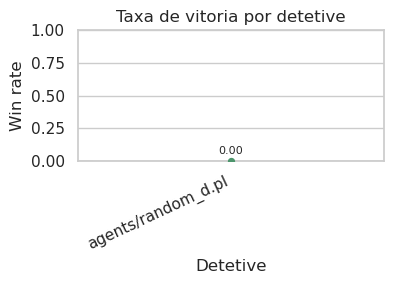

In [4]:
plot.plot_win_rates(summary, FIGS_DIR, plt, sns, close=False)
plt.show()
plt.close()


## Resultados

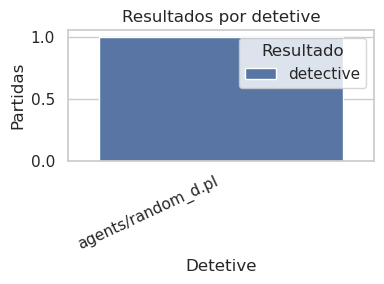

In [5]:
plot.plot_outcomes(matches, FIGS_DIR, plt, sns, close=False)
plt.show()
plt.close()


## Score por rodada

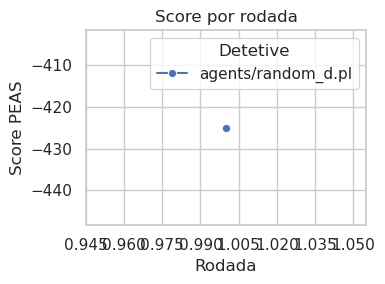

In [6]:
plot.plot_score_over_rounds(matches, FIGS_DIR, plt, sns, mticker, close=False)
plt.show()
plt.close()


## Metricas medias

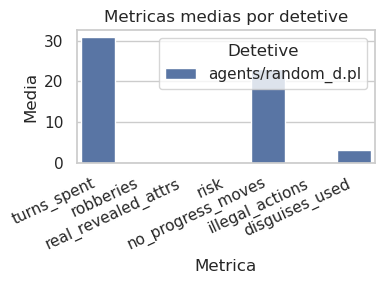

In [7]:
plot.plot_key_metrics(matches, FIGS_DIR, plt, sns, pd, close=False)
plt.show()
plt.close()


## Motivos de derrota

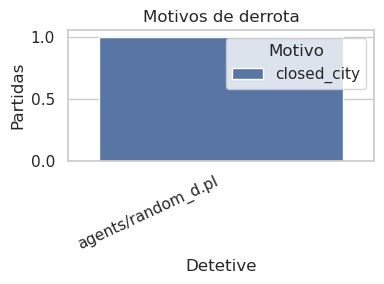

In [8]:
plot.plot_loss_reasons(matches, FIGS_DIR, plt, sns, close=False)
plt.show()
plt.close()


## Pior, media e melhor score

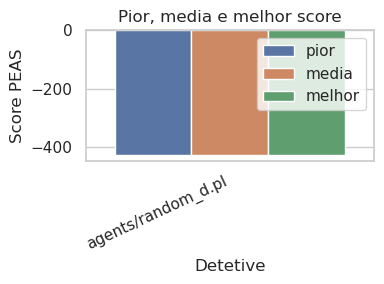

In [9]:
plot.plot_best_worst(summary, FIGS_DIR, plt, sns, pd, close=False)
plt.show()
plt.close()


## Score vs exposicao de pistas

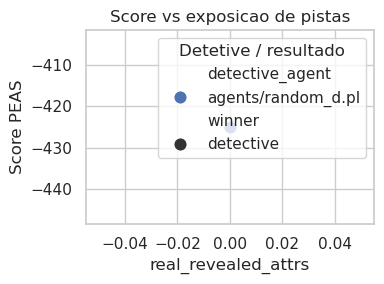

In [10]:
plot.plot_score_vs_exposure(matches, FIGS_DIR, plt, sns, close=False)
plt.show()
plt.close()


## Gerar todos de uma vez

Opcional: use esta celula quando quiser regenerar todos os PNGs sem renderizar um por celula.

In [11]:
# plot.plot_all(RESULT_DIR, pd, plt, sns, mticker)
